# Stage 4 EDA Analysis

This notebook turns the synthetic Stage 3 data into evidence for the five business findings.
Each block answers one business question and saves charts into `outputs/charts/`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

charts_dir = Path('../outputs/charts')
charts_dir.mkdir(parents=True, exist_ok=True)

In [2]:
# Load all tables
cp = pd.read_csv('../data/customer_profile.csv')
ld = pd.read_csv('../data/loan_details.csv')
lo = pd.read_csv('../data/loan_outcome.csv')
rb = pd.read_csv('../data/repayment_behavior.csv')
bs = pd.read_csv('../data/behavioral_signals.csv')

# Master merged table
merged = ld.merge(lo[['loan_id', 'default_flag']], on='loan_id')
merged = merged.merge(
    cp[['customer_id', 'employment_type', 'city_tier', 'acquisition_channel', 'credit_score', 'monthly_income']],
    on='customer_id'
)

merged_path = Path('../outputs/merged_stage4.csv')
merged_path.parent.mkdir(parents=True, exist_ok=True)
merged.to_csv(merged_path, index=False)

# Shared helper tables used across analysis blocks
merged['origination_date'] = pd.to_datetime(merged['origination_date'])
merged['origination_month'] = merged['origination_date'].dt.to_period('M').astype(str)
rb_loan = rb.merge(lo[['loan_id', 'customer_id', 'default_flag', 'default_month']], on=['loan_id', 'customer_id'], how='left')
bs_customer = bs.merge(cp[['customer_id', 'employment_type', 'city_tier', 'acquisition_channel', 'credit_score']], on='customer_id', how='left')
customer_default = lo.groupby('customer_id', as_index=False)['default_flag'].max().rename(columns={'default_flag': 'customer_default_flag'})
customer_default = customer_default.merge(cp[['customer_id', 'employment_type', 'city_tier', 'acquisition_channel', 'credit_score']], on='customer_id', how='left')

def save_chart(filename):
    plt.tight_layout()
    plt.savefig(charts_dir / filename, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

employment_order = ['Salaried', 'Gig Worker', 'Self Employed', 'Student', 'Business Owner']
city_order = ['Tier 1', 'Tier 2', 'Tier 3']
channel_order = ['Organic', 'Social Media', 'Referral', 'DSA Agent']
product_order = ['BNPL', 'Education Loan', 'Personal Loan', 'SME Loan']
risk_order = ['A', 'B', 'C', 'D']

print('All tables loaded successfully')
print(f'Master merged table: {len(merged)} rows')
print(f'Exported merged table to {merged_path}')

All tables loaded successfully
Master merged table: 12000 rows
Exported merged table to ..\outputs\merged_stage4.csv


## Block 1 — Customer Profile Analysis

Business question: Who are LendItEazy's customers?

C:\Users\sarad\AppData\Local\Temp\ipykernel_6964\1464178808.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emp_counts.index, y=emp_counts.values, palette='Blues_r', ax=ax)


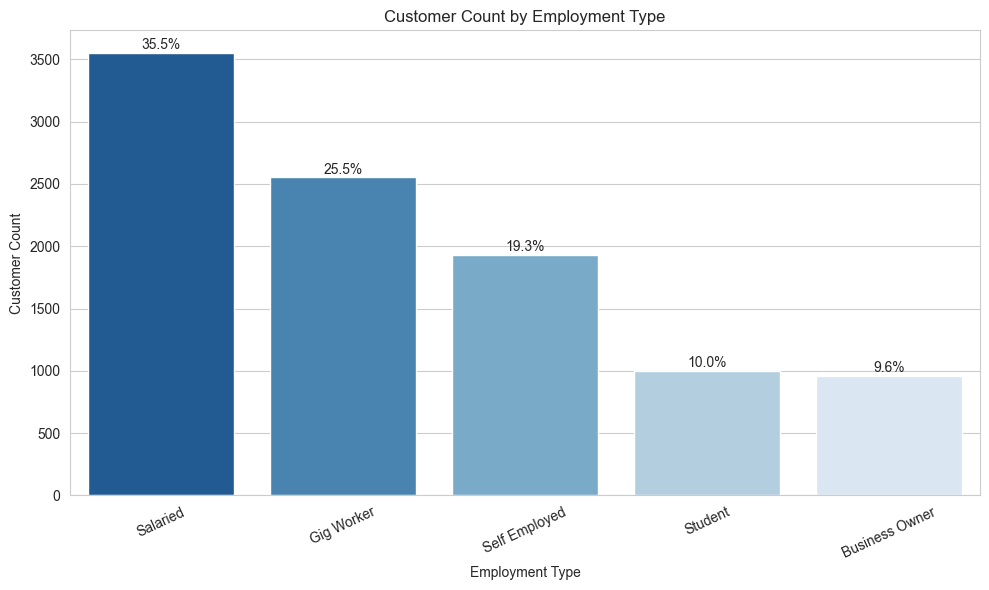

C:\Users\sarad\AppData\Local\Temp\ipykernel_6964\1464178808.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.index, y=city_counts.values, palette='Greens_r', ax=ax)


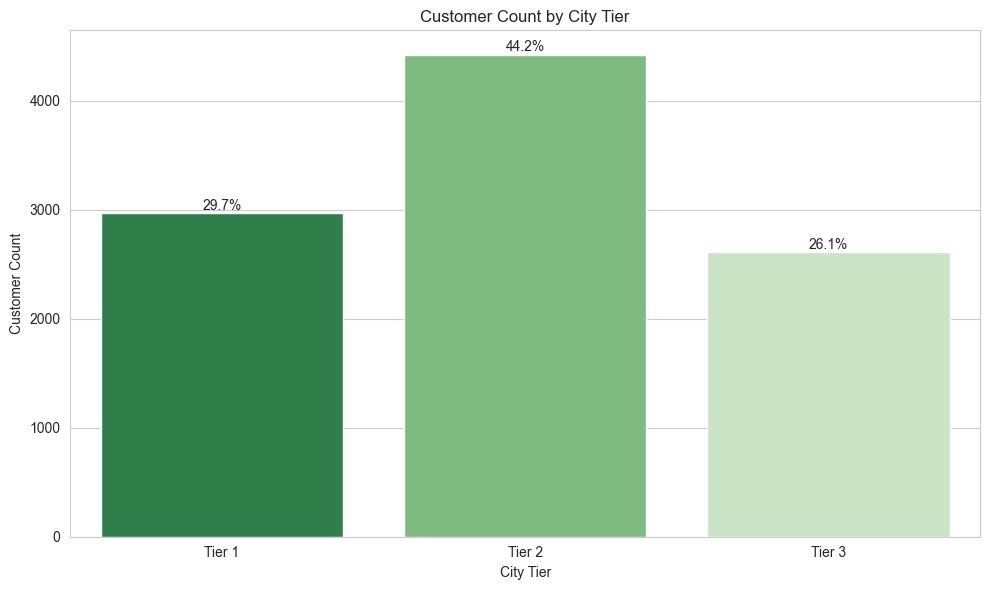

C:\Users\sarad\AppData\Local\Temp\ipykernel_6964\1464178808.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_counts.index, y=channel_counts.values, palette='Oranges_r', ax=ax)


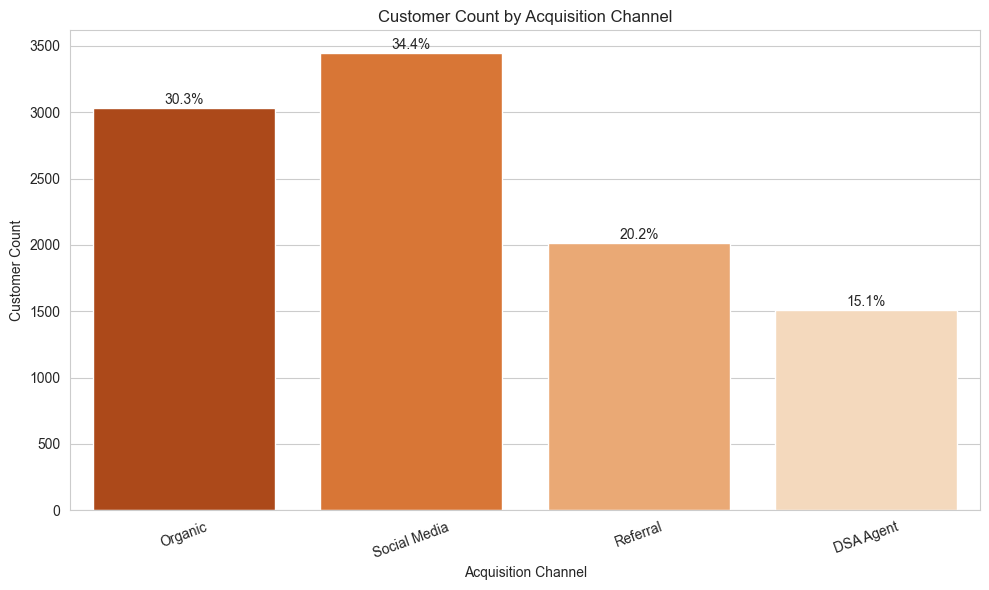

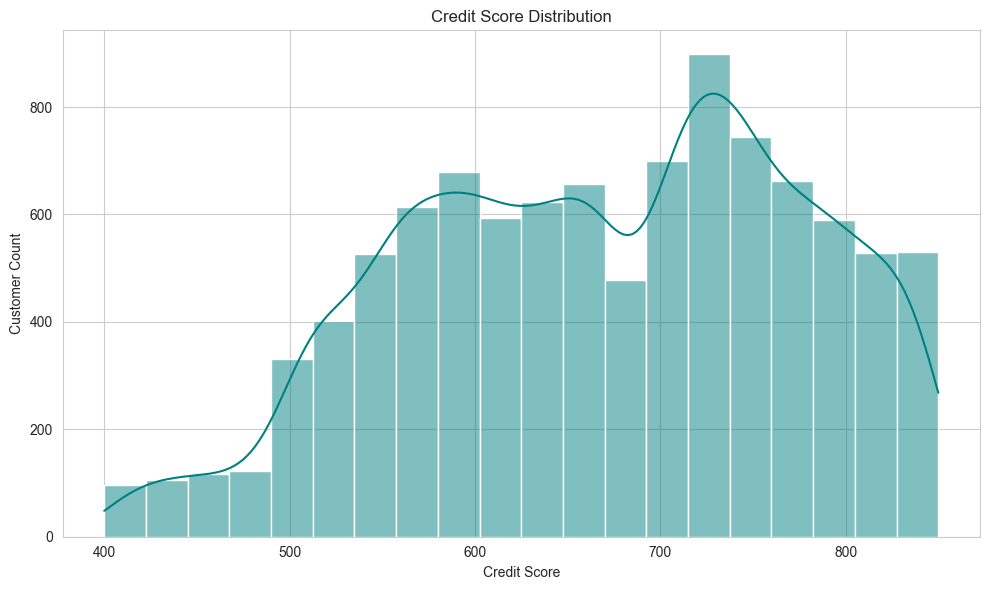

C:\Users\sarad\AppData\Local\Temp\ipykernel_6964\1464178808.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cp, x='employment_type', y='monthly_income', order=employment_order, palette='Set3', ax=ax)


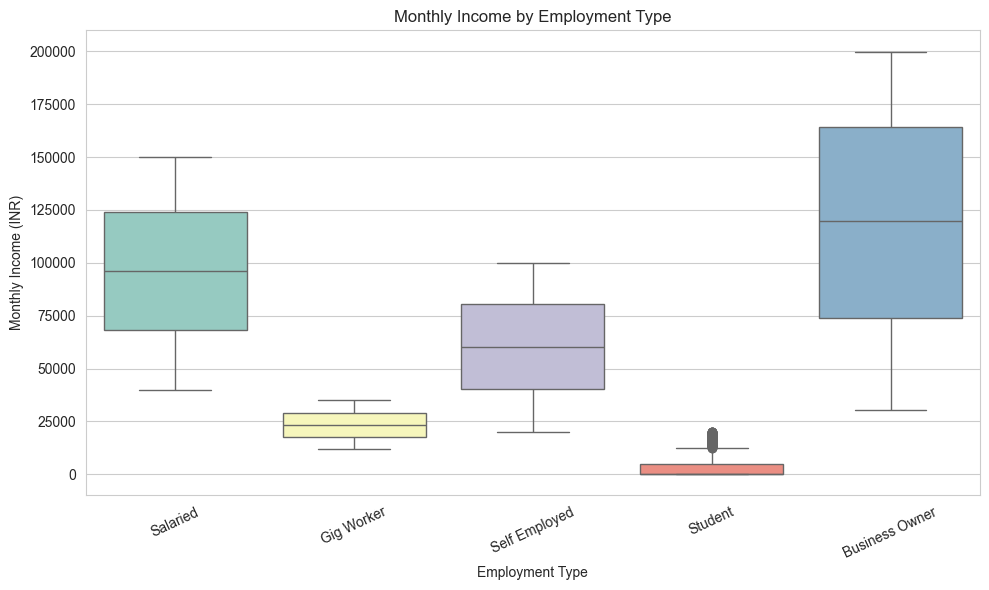

In [3]:
# Block 1: Customer Profile Analysis
# Observation: This block shows who LendItEazy lends to and where risk is concentrated in the customer base.
# Business Implication: If the customer mix is skewed toward low-score or high-volatility segments, pricing and approvals must compensate.
# Recommendation: Tighten underwriting and segment pricing for the riskiest customer groups.

employment_order = ['Salaried', 'Gig Worker', 'Self Employed', 'Student', 'Business Owner']
city_order = ['Tier 1', 'Tier 2', 'Tier 3']
channel_order = ['Organic', 'Social Media', 'Referral', 'DSA Agent']

# Chart 1 - Employment type distribution
emp_counts = cp['employment_type'].value_counts().reindex(employment_order)
emp_pct = emp_counts / len(cp) * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=emp_counts.index, y=emp_counts.values, palette='Blues_r', ax=ax)
ax.set_title('Customer Count by Employment Type')
ax.set_xlabel('Employment Type')
ax.set_ylabel('Customer Count')
ax.tick_params(axis='x', rotation=25)
for idx, value in enumerate(emp_counts.values):
    ax.text(idx, value + 30, f'{emp_pct.iloc[idx]:.1f}%', ha='center')
save_chart('01_employment_distribution.png')

# Chart 2 - City tier distribution
city_counts = cp['city_tier'].value_counts().reindex(city_order)
city_pct = city_counts / len(cp) * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=city_counts.index, y=city_counts.values, palette='Greens_r', ax=ax)
ax.set_title('Customer Count by City Tier')
ax.set_xlabel('City Tier')
ax.set_ylabel('Customer Count')
for idx, value in enumerate(city_counts.values):
    ax.text(idx, value + 30, f'{city_pct.iloc[idx]:.1f}%', ha='center')
save_chart('02_city_tier_distribution.png')

# Chart 3 - Acquisition channel distribution
channel_counts = cp['acquisition_channel'].value_counts().reindex(channel_order)
channel_pct = channel_counts / len(cp) * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=channel_counts.index, y=channel_counts.values, palette='Oranges_r', ax=ax)
ax.set_title('Customer Count by Acquisition Channel')
ax.set_xlabel('Acquisition Channel')
ax.set_ylabel('Customer Count')
ax.tick_params(axis='x', rotation=20)
for idx, value in enumerate(channel_counts.values):
    ax.text(idx, value + 30, f'{channel_pct.iloc[idx]:.1f}%', ha='center')
save_chart('03_acquisition_channel_distribution.png')

# Chart 4 - Credit score distribution
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(cp['credit_score'], bins=20, kde=True, color='teal', ax=ax)
ax.set_title('Credit Score Distribution')
ax.set_xlabel('Credit Score')
ax.set_ylabel('Customer Count')
save_chart('04_credit_score_distribution.png')

# Chart 5 - Income distribution by employment type
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=cp, x='employment_type', y='monthly_income', order=employment_order, palette='Set3', ax=ax)
ax.set_title('Monthly Income by Employment Type')
ax.set_xlabel('Employment Type')
ax.set_ylabel('Monthly Income (INR)')
ax.tick_params(axis='x', rotation=25)
save_chart('05_income_by_employment.png')

Observation:
What the customer profile charts show in one line.

Business Implication:
What this means for LendItEazy.

Recommendation:
What should be done about it.

## Block 2 — Risk Segmentation Analysis

Business question: Which customer segments default the most and why?

C:\Users\sarad\AppData\Local\Temp\ipykernel_6964\1302409807.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=default_by_emp.values, y=default_by_emp.index, palette='Reds_r', ax=ax)


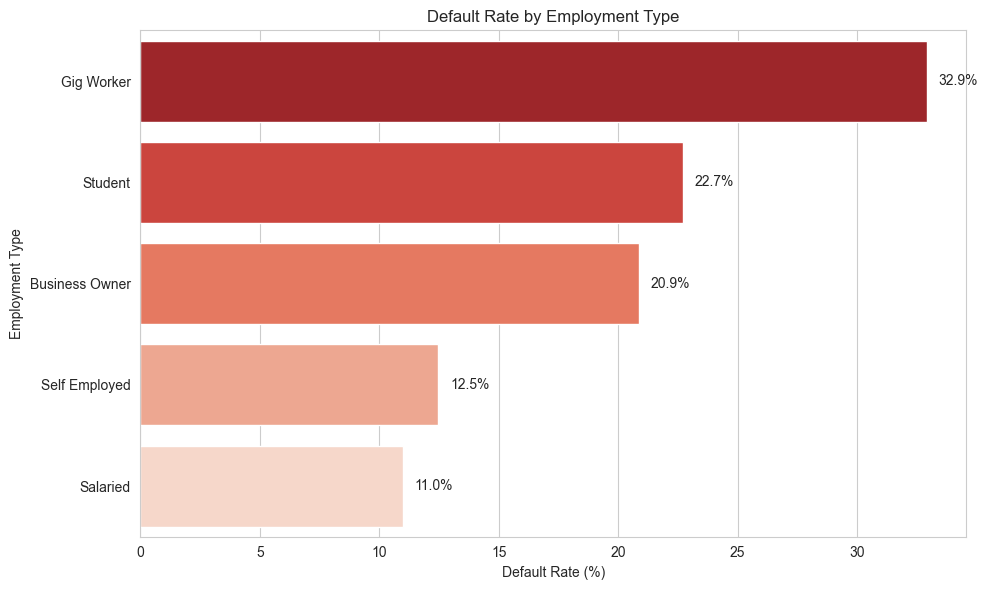

C:\Users\sarad\AppData\Local\Temp\ipykernel_6964\1302409807.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=default_by_product.index, y=default_by_product.values, palette='Purples_r', ax=ax)


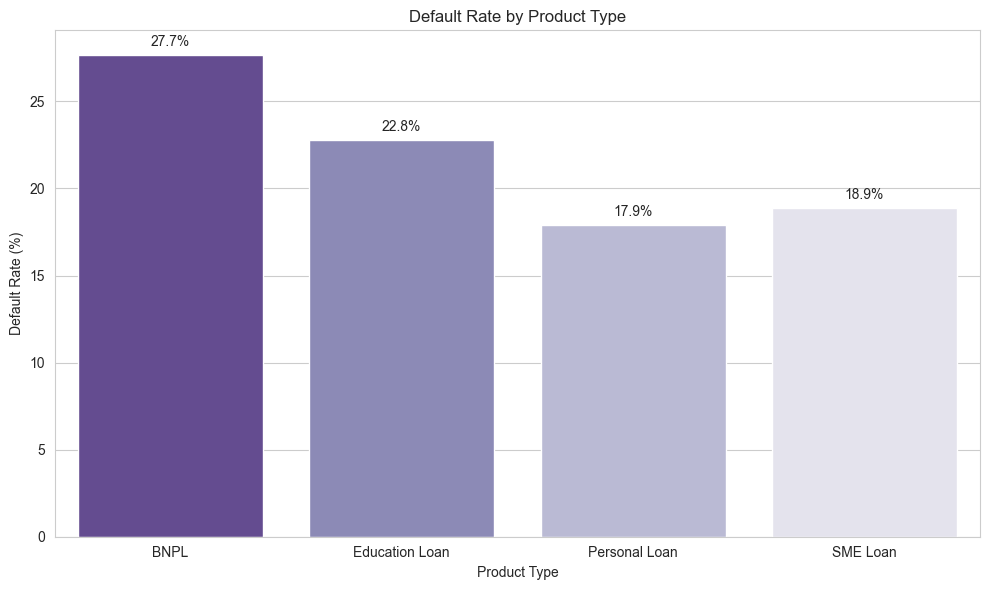

C:\Users\sarad\AppData\Local\Temp\ipykernel_6964\1302409807.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=default_by_city.index, y=default_by_city.values, palette='Greens_r', ax=ax)


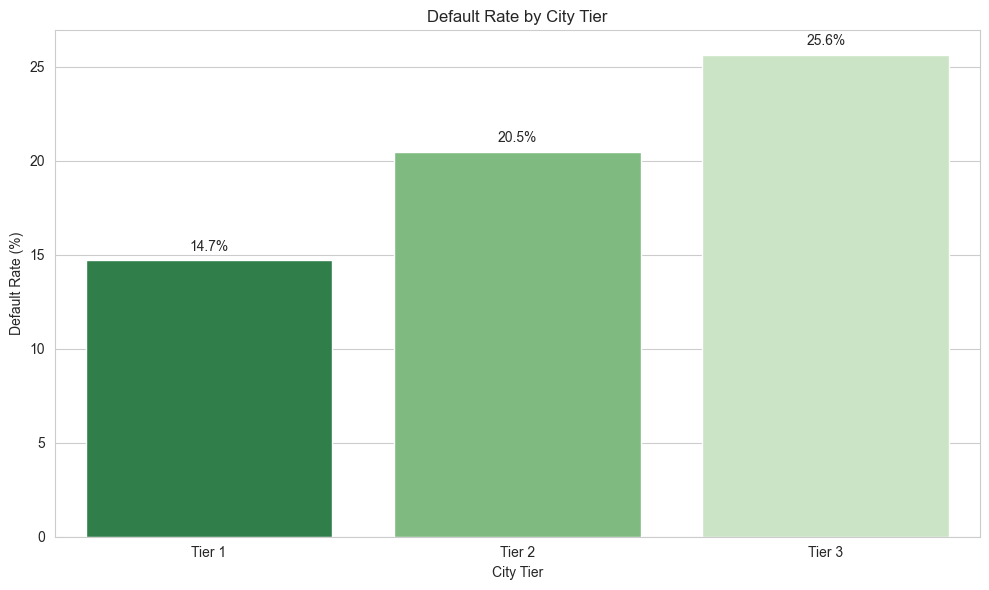

C:\Users\sarad\AppData\Local\Temp\ipykernel_6964\1302409807.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=default_by_channel.index, y=default_by_channel.values, palette='Oranges_r', ax=ax)


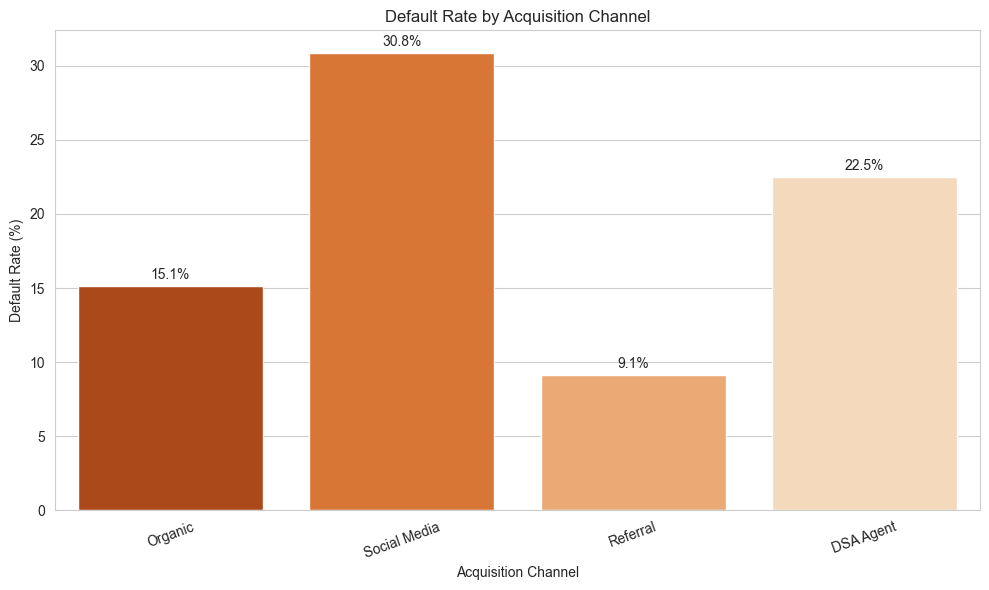

C:\Users\sarad\AppData\Local\Temp\ipykernel_6964\1302409807.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=default_by_grade.index, y=default_by_grade.values, palette='magma_r', ax=ax)


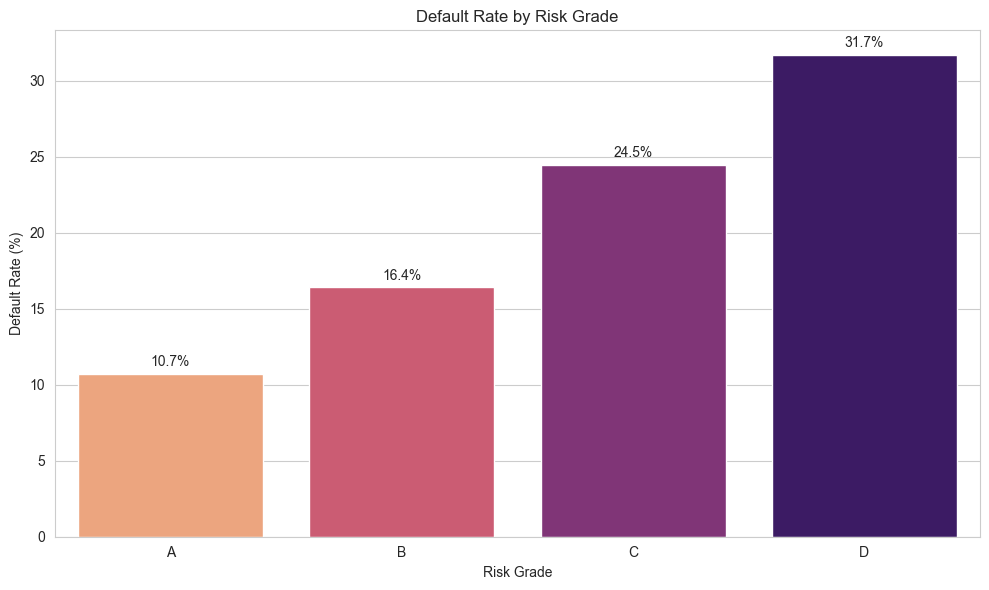

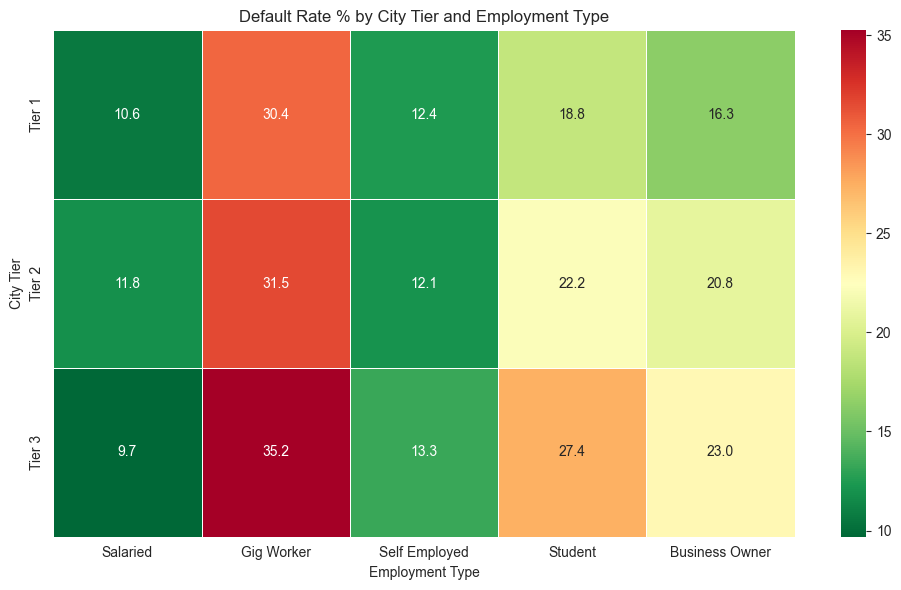

C:\Users\sarad\AppData\Local\Temp\ipykernel_6964\1302409807.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=credit_compare, x='default_label', y='credit_score', palette='Set2', ax=ax)


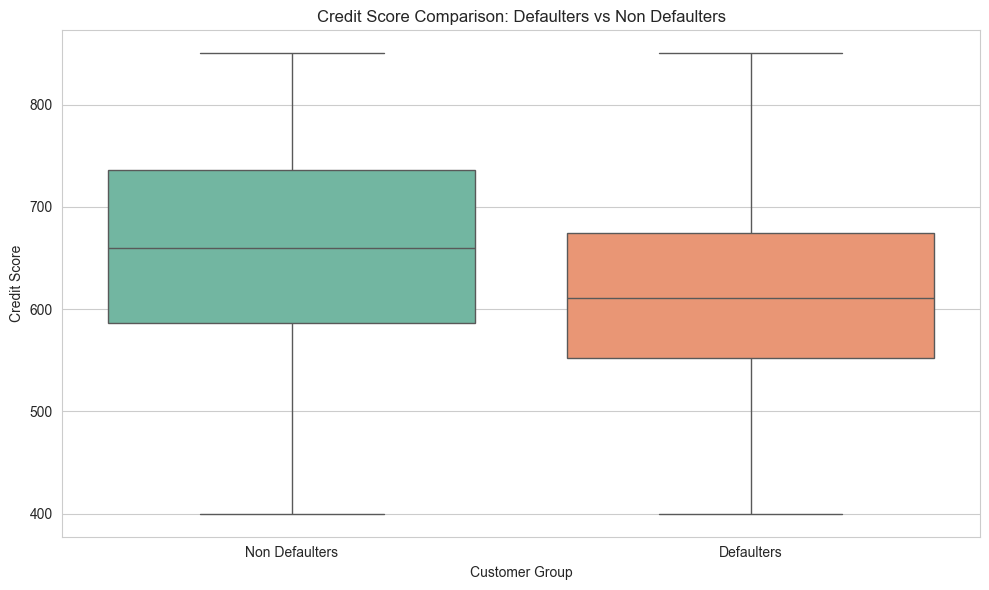

In [4]:
# Block 2: Risk Segmentation Analysis
# Observation: This block shows which segments convert into defaults the fastest and where risk compounds.
# Business Implication: The same product can behave very differently across employment, city, and channel combinations.
# Recommendation: Use segment-specific limits and pricing rather than a single portfolio-wide rule.

product_order = ['BNPL', 'Education Loan', 'Personal Loan', 'SME Loan']
risk_order = ['A', 'B', 'C', 'D']

# Chart 1 - Default rate by employment type
default_by_emp = merged.groupby('employment_type')['default_flag'].mean().reindex(employment_order).sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=default_by_emp.values, y=default_by_emp.index, palette='Reds_r', ax=ax)
ax.set_title('Default Rate by Employment Type')
ax.set_xlabel('Default Rate (%)')
ax.set_ylabel('Employment Type')
for idx, value in enumerate(default_by_emp.values):
    ax.text(value + 0.5, idx, f'{value:.1f}%', va='center')
save_chart('06_default_by_employment.png')

# Chart 2 - Default rate by product type
default_by_product = merged.groupby('product_type')['default_flag'].mean().reindex(product_order) * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=default_by_product.index, y=default_by_product.values, palette='Purples_r', ax=ax)
ax.set_title('Default Rate by Product Type')
ax.set_xlabel('Product Type')
ax.set_ylabel('Default Rate (%)')
for idx, value in enumerate(default_by_product.values):
    ax.text(idx, value + 0.5, f'{value:.1f}%', ha='center')
save_chart('07_default_by_product.png')

# Chart 3 - Default rate by city tier
default_by_city = merged.groupby('city_tier')['default_flag'].mean().reindex(city_order) * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=default_by_city.index, y=default_by_city.values, palette='Greens_r', ax=ax)
ax.set_title('Default Rate by City Tier')
ax.set_xlabel('City Tier')
ax.set_ylabel('Default Rate (%)')
for idx, value in enumerate(default_by_city.values):
    ax.text(idx, value + 0.5, f'{value:.1f}%', ha='center')
save_chart('08_default_by_city_tier.png')

# Chart 4 - Default rate by acquisition channel
default_by_channel = merged.groupby('acquisition_channel')['default_flag'].mean().reindex(channel_order) * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=default_by_channel.index, y=default_by_channel.values, palette='Oranges_r', ax=ax)
ax.set_title('Default Rate by Acquisition Channel')
ax.set_xlabel('Acquisition Channel')
ax.set_ylabel('Default Rate (%)')
ax.tick_params(axis='x', rotation=20)
for idx, value in enumerate(default_by_channel.values):
    ax.text(idx, value + 0.5, f'{value:.1f}%', ha='center')
save_chart('09_default_by_channel.png')

# Chart 5 - Default rate by risk grade
default_by_grade = merged.groupby('risk_grade')['default_flag'].mean().reindex(risk_order) * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=default_by_grade.index, y=default_by_grade.values, palette='magma_r', ax=ax)
ax.set_title('Default Rate by Risk Grade')
ax.set_xlabel('Risk Grade')
ax.set_ylabel('Default Rate (%)')
for idx, value in enumerate(default_by_grade.values):
    ax.text(idx, value + 0.5, f'{value:.1f}%', ha='center')
save_chart('10_default_by_risk_grade.png')

# Chart 6 - Risk heatmap: employment type vs city tier
risk_heatmap = merged.pivot_table(values='default_flag', index='city_tier', columns='employment_type', aggfunc='mean').reindex(index=city_order, columns=employment_order) * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(risk_heatmap, annot=True, fmt='.1f', cmap='RdYlGn_r', linewidths=0.5, ax=ax)
ax.set_title('Default Rate % by City Tier and Employment Type')
ax.set_xlabel('Employment Type')
ax.set_ylabel('City Tier')
save_chart('11_risk_heatmap.png')

# Chart 7 - Credit score comparison for defaulters vs non defaulters
fig, ax = plt.subplots(figsize=(10, 6))
credit_compare = merged.copy()
credit_compare['default_label'] = credit_compare['default_flag'].map({0: 'Non Defaulters', 1: 'Defaulters'})
sns.boxplot(data=credit_compare, x='default_label', y='credit_score', palette='Set2', ax=ax)
ax.set_title('Credit Score Comparison: Defaulters vs Non Defaulters')
ax.set_xlabel('Customer Group')
ax.set_ylabel('Credit Score')
save_chart('12_credit_score_by_default_status.png')

Observation:
What the risk charts show in one line.

Business Implication:
What this means for LendItEazy.

Recommendation:
What should be done about it.

## Block 3 — Portfolio and Channel Analysis

Business question: Which products and channels are actually profitable?

C:\Users\sarad\AppData\Local\Temp\ipykernel_6964\1273437535.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loan_volume.index, y=loan_volume.values, palette='viridis', ax=ax)


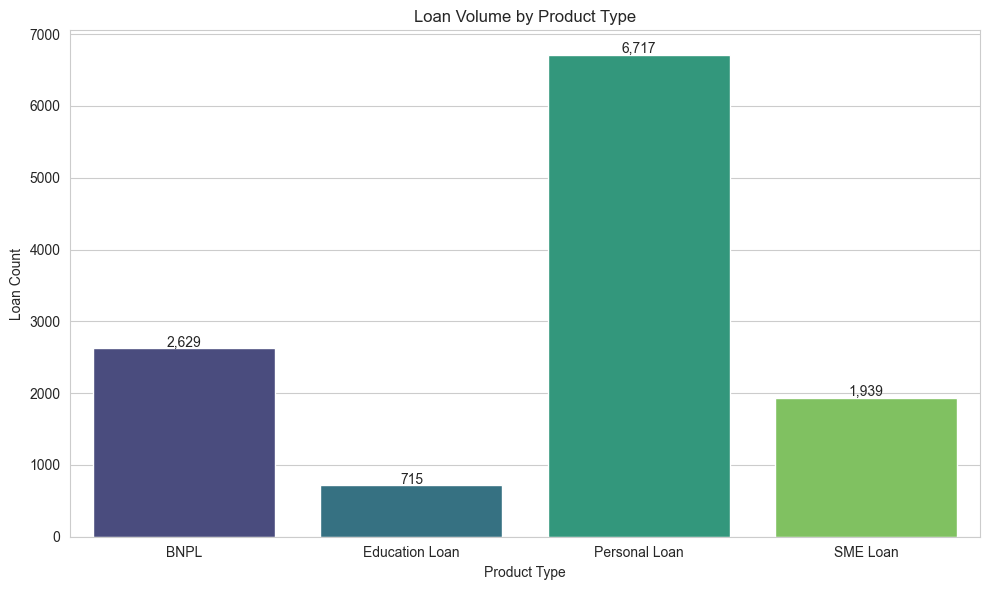

C:\Users\sarad\AppData\Local\Temp\ipykernel_6964\1273437535.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_loan_amount.index, y=avg_loan_amount.values, palette='crest', ax=ax)


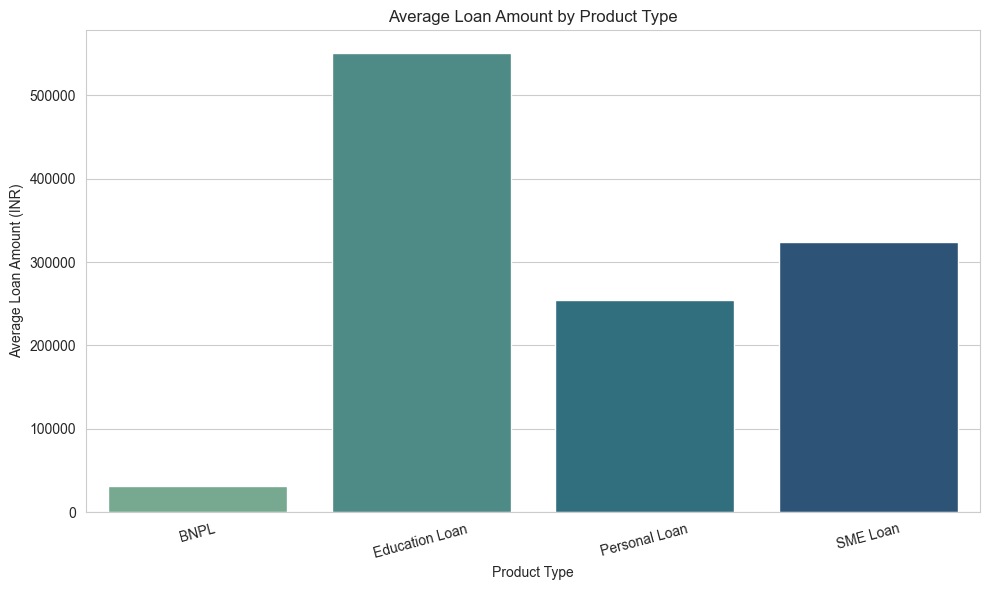

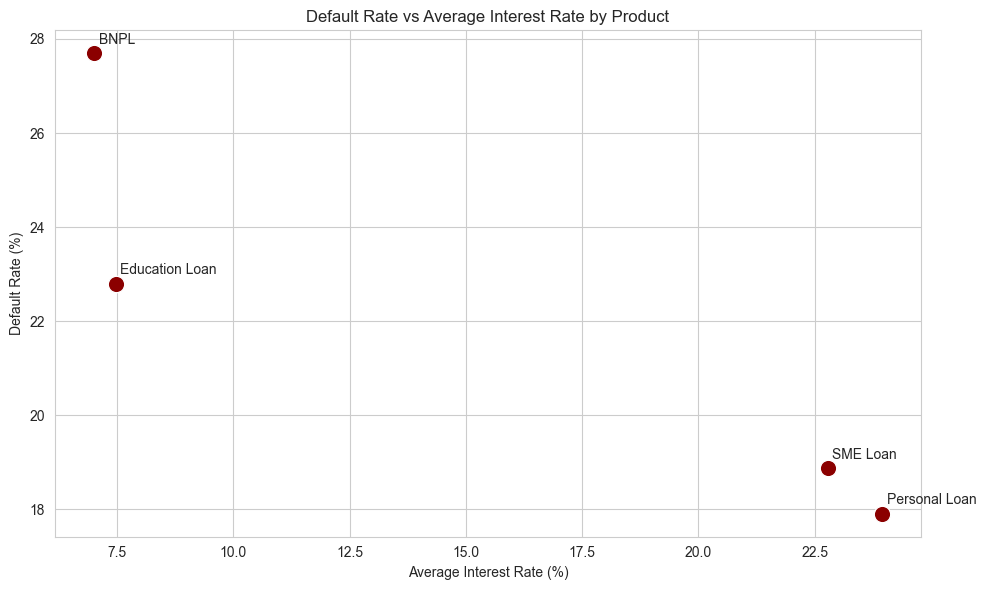

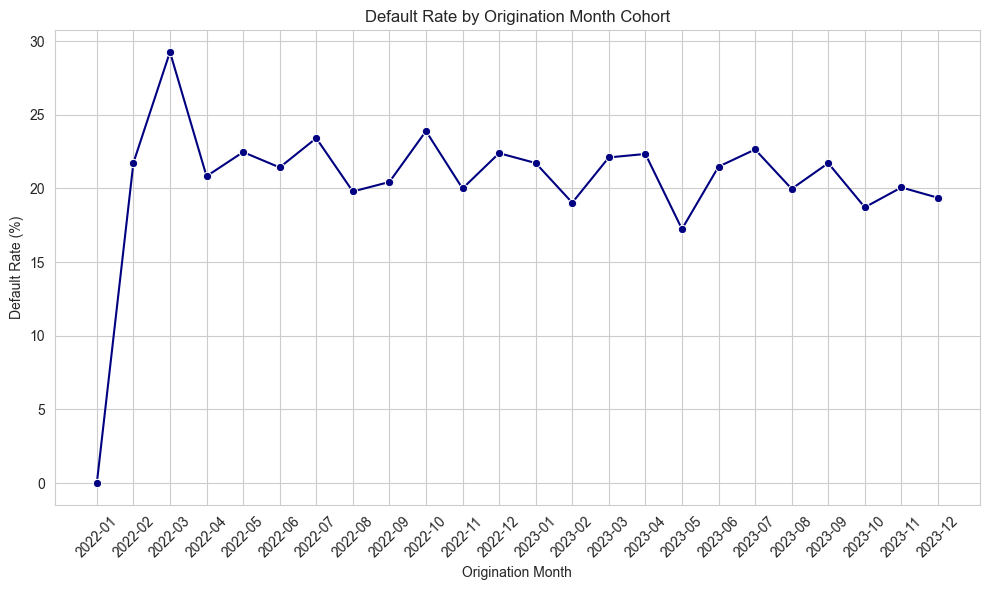

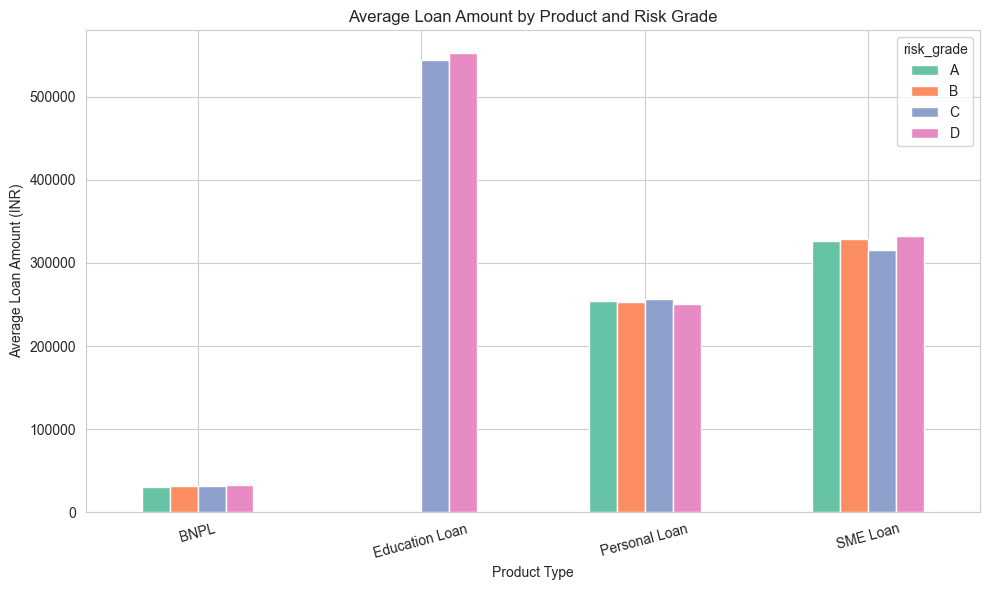

In [5]:
# Block 3: Portfolio and Channel Analysis
# Observation: This block shows which products are scaled the most and which ones need tighter profitability control.
# Business Implication: High-volume products with high defaults can dominate losses even if the average ticket is small.
# Recommendation: Match product growth with loss controls and pricing discipline.

# Chart 1 - Loan volume by product type
loan_volume = ld['product_type'].value_counts().reindex(product_order)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=loan_volume.index, y=loan_volume.values, palette='viridis', ax=ax)
ax.set_title('Loan Volume by Product Type')
ax.set_xlabel('Product Type')
ax.set_ylabel('Loan Count')
for idx, value in enumerate(loan_volume.values):
    ax.text(idx, value + 20, f'{value:,}', ha='center')
save_chart('13_loan_volume_by_product.png')

# Chart 2 - Average loan amount by product type
avg_loan_amount = ld.groupby('product_type')['loan_amount'].mean().reindex(product_order)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=avg_loan_amount.index, y=avg_loan_amount.values, palette='crest', ax=ax)
ax.set_title('Average Loan Amount by Product Type')
ax.set_xlabel('Product Type')
ax.set_ylabel('Average Loan Amount (INR)')
ax.tick_params(axis='x', rotation=15)
save_chart('14_avg_loan_amount_by_product.png')

# Chart 3 - Default rate vs average interest rate by product
product_pricing = merged.groupby('product_type').agg(default_rate=('default_flag', 'mean'), avg_interest=('interest_rate', 'mean')).reindex(product_order).reset_index()
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=product_pricing, x='avg_interest', y=product_pricing['default_rate'] * 100, s=140, color='darkred', ax=ax)
for _, row in product_pricing.iterrows():
    ax.text(row['avg_interest'] + 0.1, row['default_rate'] * 100 + 0.2, row['product_type'])
ax.set_title('Default Rate vs Average Interest Rate by Product')
ax.set_xlabel('Average Interest Rate (%)')
ax.set_ylabel('Default Rate (%)')
save_chart('15_default_vs_interest_by_product.png')

# Chart 4 - Cohort analysis by origination month
cohort = merged.groupby('origination_month')['default_flag'].mean().reset_index()
cohort = cohort.sort_values('origination_month')
cohort['default_rate_pct'] = cohort['default_flag'] * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=cohort, x='origination_month', y='default_rate_pct', marker='o', color='navy', ax=ax)
ax.set_title('Default Rate by Origination Month Cohort')
ax.set_xlabel('Origination Month')
ax.set_ylabel('Default Rate (%)')
ax.tick_params(axis='x', rotation=45)
save_chart('16_cohort_default_rate.png')

# Chart 5 - Average loan amount by product and risk grade
avg_amt_grade = merged.pivot_table(values='loan_amount', index='product_type', columns='risk_grade', aggfunc='mean').reindex(index=product_order, columns=risk_order)
fig, ax = plt.subplots(figsize=(10, 6))
avg_amt_grade.plot(kind='bar', ax=ax, color=sns.color_palette('Set2'))
ax.set_title('Average Loan Amount by Product and Risk Grade')
ax.set_xlabel('Product Type')
ax.set_ylabel('Average Loan Amount (INR)')
ax.tick_params(axis='x', rotation=15)
save_chart('17_avg_loan_amount_by_product_and_risk_grade.png')

Observation:
What the portfolio charts show in one line.

Business Implication:
What this means for LendItEazy.

Recommendation:
What should be done about it.

## Block 4 — Early Warning Signal Analysis

Business question: Can we detect defaulters before they default?

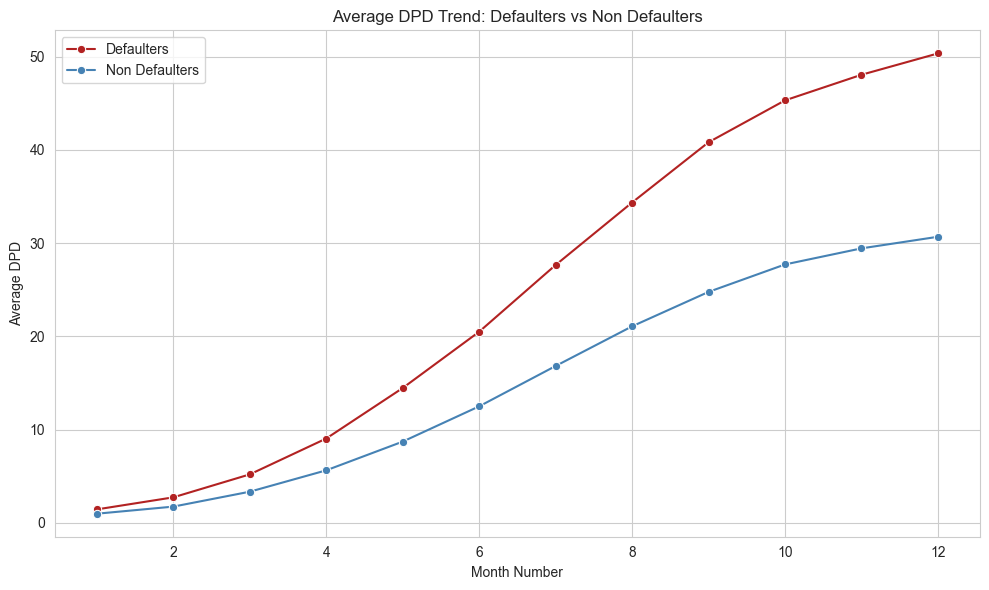

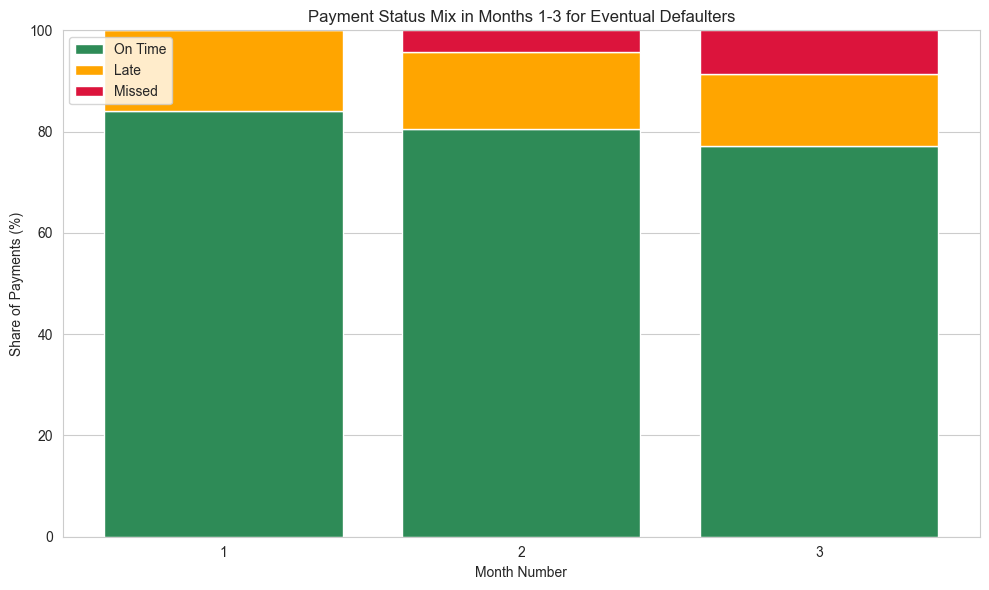

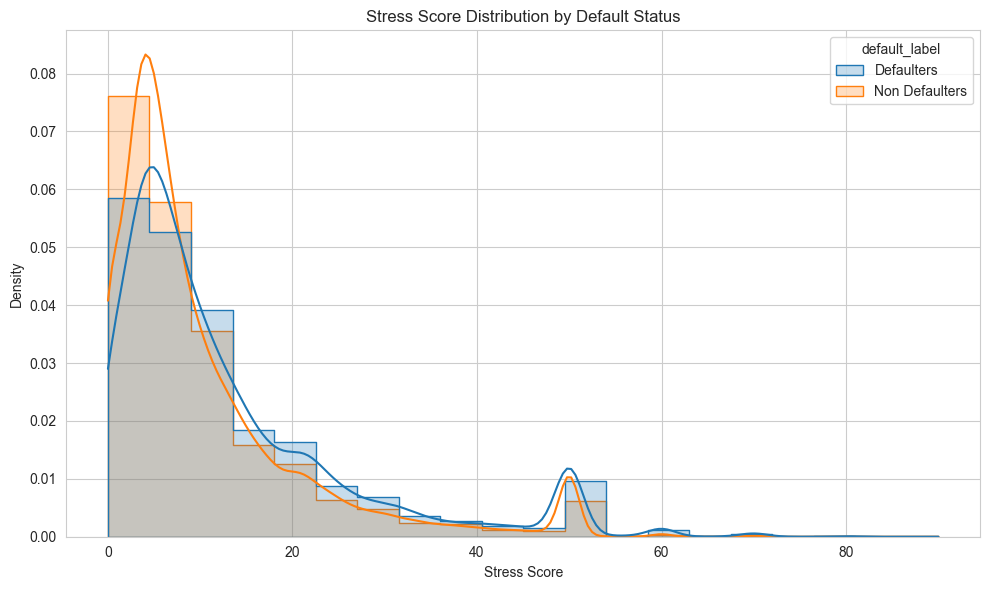

C:\Users\sarad\AppData\Local\Temp\ipykernel_6964\548647236.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=volatility_default.index, y=volatility_default.values, palette='rocket', ax=ax)


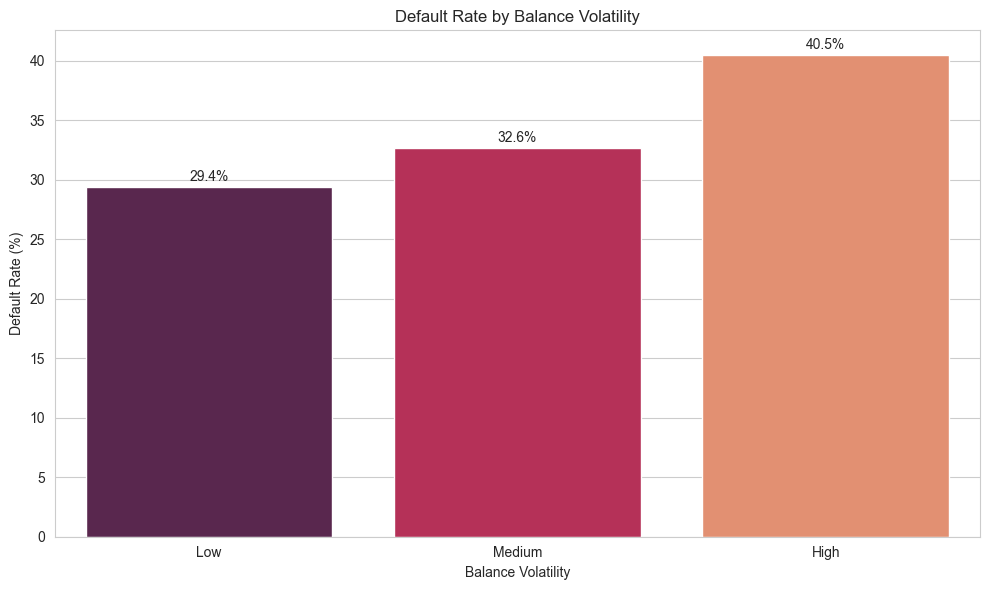

C:\Users\sarad\AppData\Local\Temp\ipykernel_6964\548647236.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=warning_rate.index.astype(str), y=warning_rate.values, palette='magma', ax=ax)


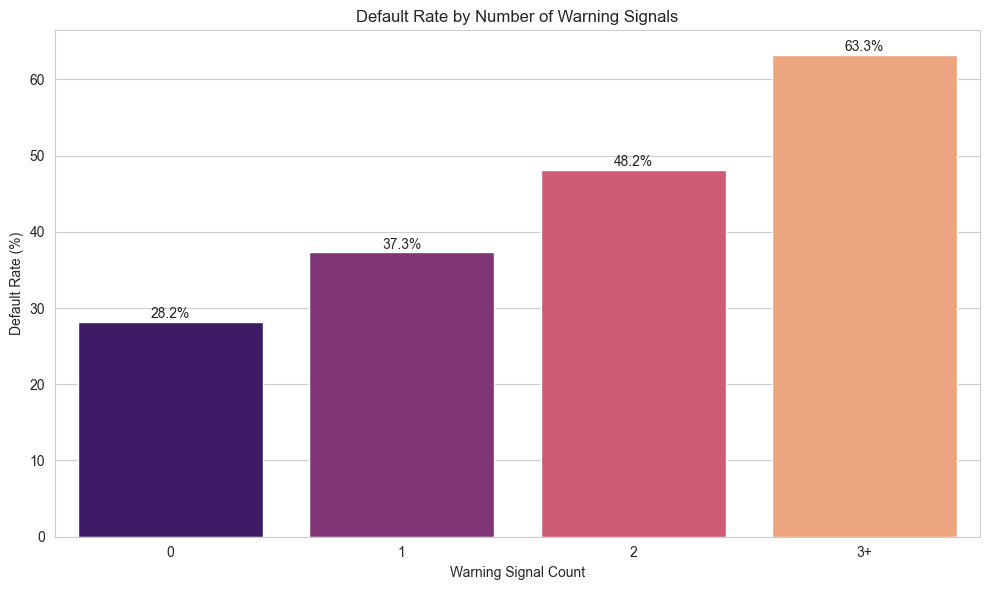

Early warning share in months 1-3: 8.8%


In [6]:
# Block 4: Early Warning Signal Analysis
# Observation: Behavioral signals should rise before default if the data is useful for intervention.
# Business Implication: If warnings appear early enough, the operations team can intervene before losses crystallize.
# Recommendation: Use DPD, inflow shocks, and stress score thresholds to drive collections triggers.

# Build a monthly repayment table with default information
rb_loan = rb.merge(lo[['loan_id', 'customer_id', 'default_flag', 'default_month']], on=['loan_id', 'customer_id'], how='left')
rb_loan['payment_status'] = rb_loan['payment_status'].fillna('Unknown')

# Chart 1 - Average DPD trend for defaulters vs non defaulters
dpd_trend = rb_loan.groupby(['month_number', 'default_flag'])['dpd'].mean().reset_index()
dpd_trend = dpd_trend[dpd_trend['month_number'] <= 12]
fig, ax = plt.subplots(figsize=(10, 6))
for flag, label, color in [(1, 'Defaulters', 'firebrick'), (0, 'Non Defaulters', 'steelblue')]:
    subset = dpd_trend[dpd_trend['default_flag'] == flag]
    sns.lineplot(data=subset, x='month_number', y='dpd', marker='o', label=label, color=color, ax=ax)
ax.set_title('Average DPD Trend: Defaulters vs Non Defaulters')
ax.set_xlabel('Month Number')
ax.set_ylabel('Average DPD')
save_chart('18_dpd_trend_defaulters_vs_nondefaulters.png')

# Chart 2 - Payment status breakdown in months 1, 2, 3 for eventual defaulters
payment_breakdown = rb_loan[(rb_loan['default_flag'] == 1) & (rb_loan['month_number'].isin([1, 2, 3]))].copy()
status_pct = pd.crosstab(payment_breakdown['month_number'], payment_breakdown['payment_status'], normalize='index').reindex(index=[1, 2, 3], fill_value=0) * 100
fig, ax = plt.subplots(figsize=(10, 6))
bottom = pd.Series([0, 0, 0], index=[1, 2, 3], dtype=float)
for status, color in [('On Time', 'seagreen'), ('Late', 'orange'), ('Missed', 'crimson')]:
    values = status_pct[status] if status in status_pct.columns else pd.Series([0, 0, 0], index=[1, 2, 3], dtype=float)
    ax.bar(status_pct.index.astype(str), values.values, bottom=bottom.values, label=status, color=color)
    bottom = bottom + values
ax.set_title('Payment Status Mix in Months 1-3 for Eventual Defaulters')
ax.set_xlabel('Month Number')
ax.set_ylabel('Share of Payments (%)')
ax.legend()
save_chart('19_payment_status_before_default.png')

# Chart 3 - Stress score distribution
stress_df = bs_customer.merge(customer_default[['customer_id', 'customer_default_flag']], on='customer_id', how='left')
stress_df['default_label'] = stress_df['customer_default_flag'].map({0: 'Non Defaulters', 1: 'Defaulters'})
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=stress_df, x='stress_score', hue='default_label', bins=20, kde=True, element='step', stat='density', common_norm=False, ax=ax)
ax.set_title('Stress Score Distribution by Default Status')
ax.set_xlabel('Stress Score')
ax.set_ylabel('Density')
save_chart('20_stress_score_distribution.png')

# Chart 4 - Balance volatility vs default rate
volatility_default = stress_df.groupby('balance_volatility')['customer_default_flag'].mean().reindex(['Low', 'Medium', 'High']) * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=volatility_default.index, y=volatility_default.values, palette='rocket', ax=ax)
ax.set_title('Default Rate by Balance Volatility')
ax.set_xlabel('Balance Volatility')
ax.set_ylabel('Default Rate (%)')
for idx, value in enumerate(volatility_default.values):
    ax.text(idx, value + 0.5, f'{value:.1f}%', ha='center')
save_chart('21_default_by_balance_volatility.png')

# Chart 5 - Default rate increases as warning signals increase
warning_df = bs_customer.merge(customer_default[['customer_id', 'customer_default_flag']], on='customer_id', how='left')
warning_df['warning_count'] = (
    warning_df['inflow_drop_flag'].eq(1).astype(int)
    + warning_df['spending_shock_flag'].eq(1).astype(int)
    + warning_df['missed_bill_payments'].gt(0).astype(int)
    + warning_df['balance_volatility'].eq('High').astype(int)
    + warning_df['stress_score'].ge(60).astype(int)
)
warning_df['warning_bucket'] = pd.cut(warning_df['warning_count'], bins=[-1, 0, 1, 2, 10], labels=['0', '1', '2', '3+'])
warning_rate = warning_df.groupby('warning_bucket')['customer_default_flag'].mean().reindex(['0', '1', '2', '3+']) * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=warning_rate.index.astype(str), y=warning_rate.values, palette='magma', ax=ax)
ax.set_title('Default Rate by Number of Warning Signals')
ax.set_xlabel('Warning Signal Count')
ax.set_ylabel('Default Rate (%)')
for idx, value in enumerate(warning_rate.values):
    ax.text(idx, value + 0.5, f'{value:.1f}%', ha='center')
save_chart('22_default_by_warning_signal_count.png')

# Supporting statistic for the CRO narrative: share of defaulters with strong warning signals in months 1-3 before default
default_loans = lo[lo['default_flag'] == 1].merge(ld[['loan_id', 'customer_id', 'origination_date']], on=['loan_id', 'customer_id'], how='left')
default_loans['origination_date'] = pd.to_datetime(default_loans['origination_date'])
default_loans['default_event_date'] = default_loans.apply(lambda row: row['origination_date'] + pd.DateOffset(months=int(row['default_month']) - 1), axis=1)
default_loans = default_loans.sort_values('default_event_date').groupby('customer_id', as_index=False).first()
warn_window = bs_customer.merge(default_loans[['customer_id', 'default_event_date']], on='customer_id', how='inner')
warn_window['month_dt'] = pd.to_datetime(warn_window['month'] + '-01')
warn_window['warning_count'] = (
    warn_window['inflow_drop_flag'].eq(1).astype(int)
    + warn_window['spending_shock_flag'].eq(1).astype(int)
    + warn_window['missed_bill_payments'].gt(0).astype(int)
    + warn_window['balance_volatility'].eq('High').astype(int)
    + warn_window['stress_score'].ge(60).astype(int)
)
warn_window['months_before_default'] = (
    (warn_window['default_event_date'].dt.year * 12 + warn_window['default_event_date'].dt.month)
    - (warn_window['month_dt'].dt.year * 12 + warn_window['month_dt'].dt.month)
)
early_warning_share = warn_window[(warn_window['months_before_default'].between(1, 3)) & (warn_window['warning_count'] >= 2)]['customer_id'].nunique() / default_loans['customer_id'].nunique() * 100
print(f'Early warning share in months 1-3: {early_warning_share:.1f}%')

Observation:
What the early-warning charts show in one line.

Business Implication:
What this means for LendItEazy.

Recommendation:
What should be done about it.

## Block 5 — Pricing Analysis

Business question: Are we charging the right interest rate for the risk we are taking?

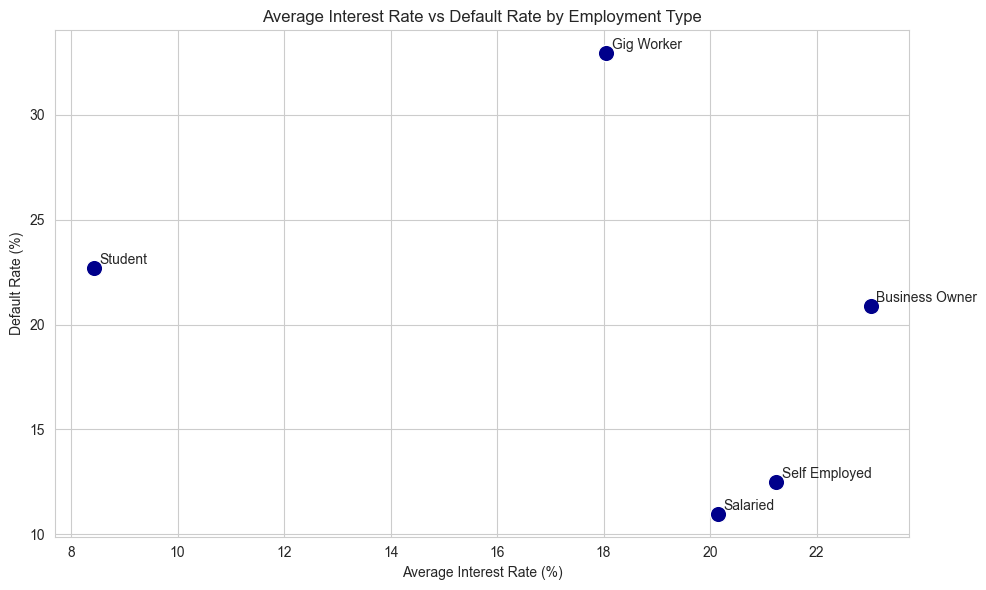

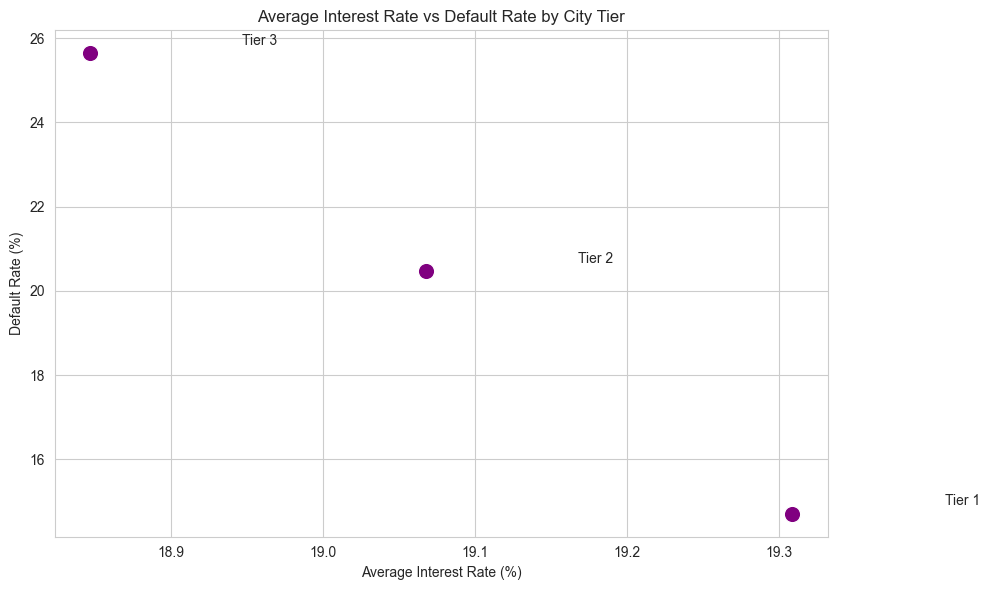

C:\Users\sarad\AppData\Local\Temp\ipykernel_6964\195507047.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pricing_emp.sort_values('pricing_gap', ascending=False), x='pricing_gap', y='employment_type', palette='coolwarm', ax=ax)


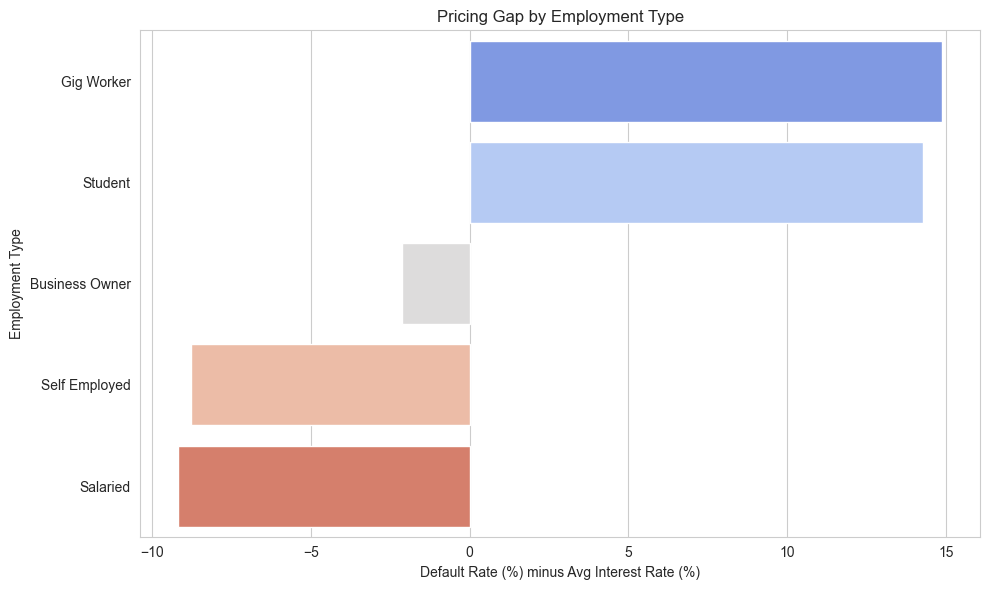

Segments that appear underpriced relative to default risk:
employment_type  avg_interest  default_rate_pct  pricing_gap
     Gig Worker     18.052219         32.918958    14.866739
        Student      8.421424         22.705882    14.284459


In [7]:
# Block 5: Pricing Analysis
# Observation: This block checks whether the current pricing curve matches the observed risk curve.
# Business Implication: Underpriced high-risk segments need repricing or tighter approval controls.
# Recommendation: Raise pricing or reduce exposure where default risk outpaces interest income.

# Chart 1 - Average interest rate vs default rate by employment type
pricing_emp = merged.groupby('employment_type').agg(avg_interest=('interest_rate', 'mean'), default_rate=('default_flag', 'mean')).reset_index()
pricing_emp['default_rate_pct'] = pricing_emp['default_rate'] * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=pricing_emp, x='avg_interest', y='default_rate_pct', s=140, color='darkblue', ax=ax)
for _, row in pricing_emp.iterrows():
    ax.text(row['avg_interest'] + 0.1, row['default_rate_pct'] + 0.2, row['employment_type'])
ax.set_title('Average Interest Rate vs Default Rate by Employment Type')
ax.set_xlabel('Average Interest Rate (%)')
ax.set_ylabel('Default Rate (%)')
save_chart('23_interest_vs_default_by_employment.png')

# Chart 2 - Average interest rate vs default rate by city tier
pricing_city = merged.groupby('city_tier').agg(avg_interest=('interest_rate', 'mean'), default_rate=('default_flag', 'mean')).reindex(city_order).reset_index()
pricing_city['default_rate_pct'] = pricing_city['default_rate'] * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=pricing_city, x='avg_interest', y='default_rate_pct', s=140, color='purple', ax=ax)
for _, row in pricing_city.iterrows():
    ax.text(row['avg_interest'] + 0.1, row['default_rate_pct'] + 0.2, row['city_tier'])
ax.set_title('Average Interest Rate vs Default Rate by City Tier')
ax.set_xlabel('Average Interest Rate (%)')
ax.set_ylabel('Default Rate (%)')
save_chart('24_interest_vs_default_by_city_tier.png')

# Chart 3 - Pricing gap by employment type
pricing_emp['pricing_gap'] = pricing_emp['default_rate_pct'] - pricing_emp['avg_interest']
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=pricing_emp.sort_values('pricing_gap', ascending=False), x='pricing_gap', y='employment_type', palette='coolwarm', ax=ax)
ax.set_title('Pricing Gap by Employment Type')
ax.set_xlabel('Default Rate (%) minus Avg Interest Rate (%)')
ax.set_ylabel('Employment Type')
save_chart('25_pricing_gap_by_employment.png')

underpriced_segments = pricing_emp[pricing_emp['pricing_gap'] > 0].sort_values('pricing_gap', ascending=False)
print('Segments that appear underpriced relative to default risk:')
print(underpriced_segments[['employment_type', 'avg_interest', 'default_rate_pct', 'pricing_gap']].to_string(index=False))

Observation:
What the pricing charts show in one line.

Business Implication:
What this means for LendItEazy.

Recommendation:
What should be done about it.

In [8]:
# Summary of Findings
summary_rows = []
overall_default = lo['default_flag'].mean() * 100
gig_default = merged.loc[merged['employment_type'] == 'Gig Worker', 'default_flag'].mean() * 100
salaried_default = merged.loc[merged['employment_type'] == 'Salaried', 'default_flag'].mean() * 100
bnpl_default = merged.loc[merged['product_type'] == 'BNPL', 'default_flag'].mean() * 100
social_default = merged.loc[merged['acquisition_channel'] == 'Social Media', 'default_flag'].mean() * 100
referral_default = merged.loc[merged['acquisition_channel'] == 'Referral', 'default_flag'].mean() * 100
tier3_default = merged.loc[merged['city_tier'] == 'Tier 3', 'default_flag'].mean() * 100

summary_rows.append({'Finding': 'Overall portfolio', 'Metric': 'Default rate', 'Value': f'{overall_default:.1f}%', 'Note': 'Portfolio is near the target band'})
summary_rows.append({'Finding': 'Finding 1', 'Metric': 'Gig worker default rate', 'Value': f'{gig_default:.1f}%', 'Note': 'Much higher than salaried customers'})
summary_rows.append({'Finding': 'Finding 1', 'Metric': 'Salaried default rate', 'Value': f'{salaried_default:.1f}%', 'Note': 'Low-risk anchor segment'})
summary_rows.append({'Finding': 'Finding 2', 'Metric': 'BNPL default rate', 'Value': f'{bnpl_default:.1f}%', 'Note': 'Highest product risk'})
summary_rows.append({'Finding': 'Finding 3', 'Metric': 'Social Media default rate', 'Value': f'{social_default:.1f}%', 'Note': 'Clearly above referral'})
summary_rows.append({'Finding': 'Finding 3', 'Metric': 'Referral default rate', 'Value': f'{referral_default:.1f}%', 'Note': 'Best-performing channel'})
summary_rows.append({'Finding': 'Finding 4', 'Metric': 'Tier 3 city default rate', 'Value': f'{tier3_default:.1f}%', 'Note': 'Underpriced relative to risk'})
summary_rows.append({'Finding': 'Finding 5', 'Metric': 'Early warning share', 'Value': f'{early_warning_share:.1f}%', 'Note': 'Defaulters with 2+ signals in months 1-3'})

summary_df = pd.DataFrame(summary_rows)
print('Stage 4 Key Numbers Summary')
print(summary_df.to_string(index=False))
summary_df.to_csv('../outputs/stage4_key_numbers_summary.csv', index=False)

Stage 4 Key Numbers Summary
          Finding                    Metric Value                                     Note
Overall portfolio              Default rate 20.5%        Portfolio is near the target band
        Finding 1   Gig worker default rate 32.9%      Much higher than salaried customers
        Finding 1     Salaried default rate 11.0%                  Low-risk anchor segment
        Finding 2         BNPL default rate 27.7%                     Highest product risk
        Finding 3 Social Media default rate 30.8%                   Clearly above referral
        Finding 3     Referral default rate  9.1%                  Best-performing channel
        Finding 4  Tier 3 city default rate 25.6%             Underpriced relative to risk
        Finding 5       Early warning share  8.8% Defaulters with 2+ signals in months 1-3
